In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

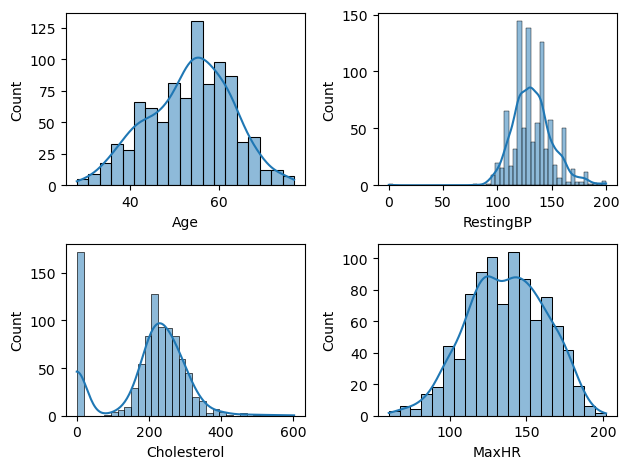

In [6]:
def plotting(var,num):
   plt.subplot(2,2,num)
   sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [3]:
ch_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol']=df['Cholesterol'].round(2)

BP_mean=df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df['RestingBP']=df['RestingBP'].replace(0,BP_mean)
df['RestingBP']=df['RestingBP'].round(2)

In [8]:
ch_mean

np.float64(244.6353887399464)

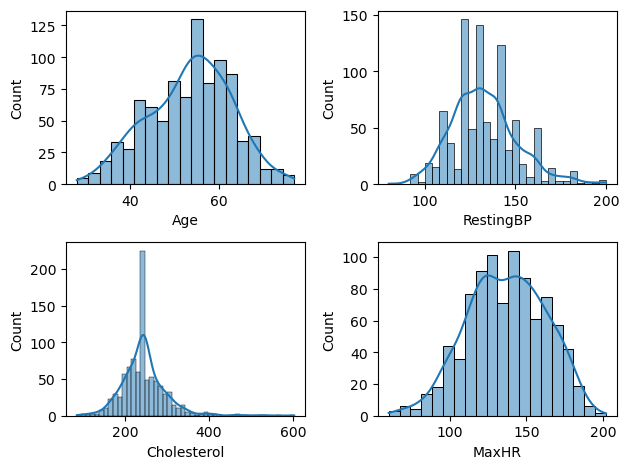

In [9]:
def plotting(var,num):
   plt.subplot(2,2,num)
   sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

<Axes: xlabel='Oldpeak', ylabel='Count'>

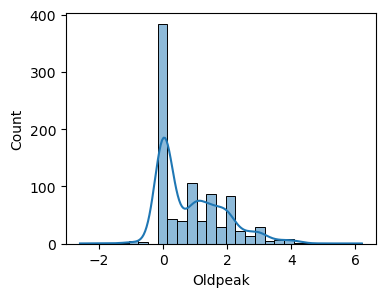

In [10]:
plt.figure(figsize=(4,3))
sns.histplot(df['Oldpeak'],kde=True)

In [4]:
df=df[(df['Oldpeak']>=0) & (df['Oldpeak']<=4)].reset_index(drop=True)

<Axes: xlabel='Oldpeak', ylabel='Count'>

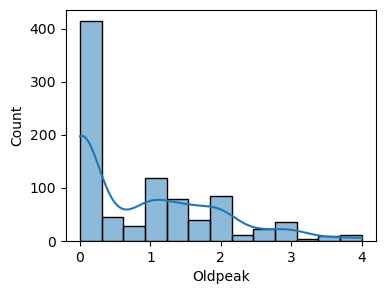

In [12]:
plt.figure(figsize=(4,3))
sns.histplot(df['Oldpeak'],kde=True)

In [5]:
df['Sex']=df['Sex'].replace({'M':'Male','F':'Female'})
df['FastingBS']=df['FastingBS'].replace({0:'Normal',1:'High'})
df['ExerciseAngina']=df['ExerciseAngina'].replace({'Y':'Yes','N':'No'})

In [12]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,Male,ATA,140.0,289.0,Normal,Normal,172,No,0.0,Up,0
1,49,Female,NAP,160.0,180.0,Normal,Normal,156,No,1.0,Flat,1
2,37,Male,ATA,130.0,283.0,Normal,ST,98,No,0.0,Up,0
3,48,Female,ASY,138.0,214.0,Normal,Normal,108,Yes,1.5,Flat,1
4,54,Male,NAP,150.0,195.0,Normal,Normal,122,No,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
894,45,Male,TA,110.0,264.0,Normal,Normal,132,No,1.2,Flat,1
895,68,Male,ASY,144.0,193.0,High,Normal,141,No,3.4,Flat,1
896,57,Male,ASY,130.0,131.0,Normal,Normal,115,Yes,1.2,Flat,1
897,57,Female,ATA,130.0,236.0,Normal,LVH,174,No,0.0,Flat,1


In [15]:
df['HeartDisease'].value_counts()

HeartDisease
1    494
0    405
Name: count, dtype: int64

In [6]:
df['age_category']=pd.cut(df['Age'],bins=[27,40,55,78],labels=['Adult','Midle-aged','Older'])
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,age_category
0,40,Male,ATA,140.0,289.0,Normal,Normal,172,No,0.0,Up,0,Adult
1,49,Female,NAP,160.0,180.0,Normal,Normal,156,No,1.0,Flat,1,Midle-aged
2,37,Male,ATA,130.0,283.0,Normal,ST,98,No,0.0,Up,0,Adult
3,48,Female,ASY,138.0,214.0,Normal,Normal,108,Yes,1.5,Flat,1,Midle-aged
4,54,Male,NAP,150.0,195.0,Normal,Normal,122,No,0.0,Up,0,Midle-aged
...,...,...,...,...,...,...,...,...,...,...,...,...,...
894,45,Male,TA,110.0,264.0,Normal,Normal,132,No,1.2,Flat,1,Midle-aged
895,68,Male,ASY,144.0,193.0,High,Normal,141,No,3.4,Flat,1,Older
896,57,Male,ASY,130.0,131.0,Normal,Normal,115,Yes,1.2,Flat,1,Older
897,57,Female,ATA,130.0,236.0,Normal,LVH,174,No,0.0,Flat,1,Older


In [7]:
df=df.drop('age_category',axis=1)

<Axes: >

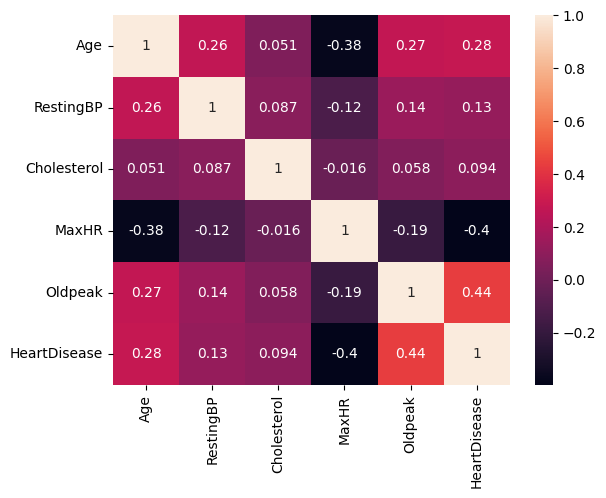

In [8]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='ExerciseAngina', ylabel='count'>

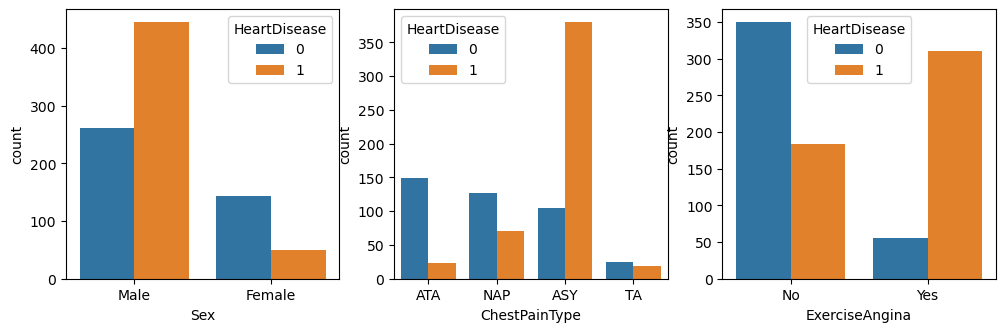

In [18]:
plt.figure(figsize=(12,3.5))
plt.subplot(1,3,1)
sns.countplot(x='Sex',hue='HeartDisease',data=df)
plt.subplot(1,3,2)
sns.countplot(x='ChestPainType',hue='HeartDisease',data=df)
plt.subplot(1,3,3)
sns.countplot(x='ExerciseAngina',hue='HeartDisease',data=df)

<Axes: xlabel='ST_Slope', ylabel='count'>

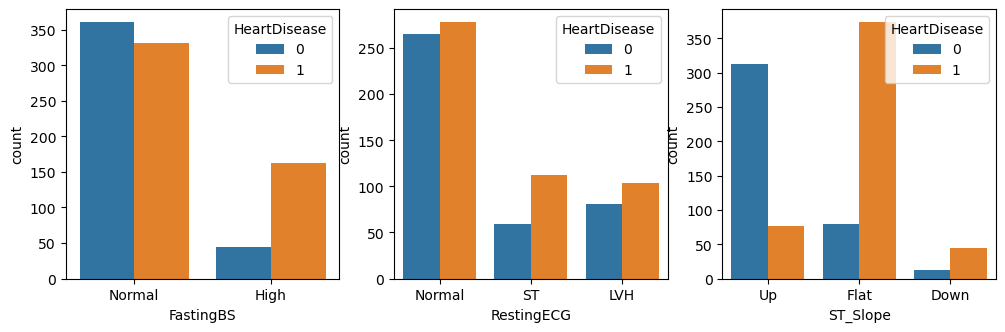

In [19]:
plt.figure(figsize=(12,3.5))
plt.subplot(1,3,1)
sns.countplot(x='FastingBS',hue='HeartDisease',data=df)
plt.subplot(1,3,2)
sns.countplot(x='RestingECG',hue='HeartDisease',data=df)
plt.subplot(1,3,3)
sns.countplot(x='ST_Slope',hue='HeartDisease',data=df)

<Axes: xlabel='HeartDisease', ylabel='MaxHR'>

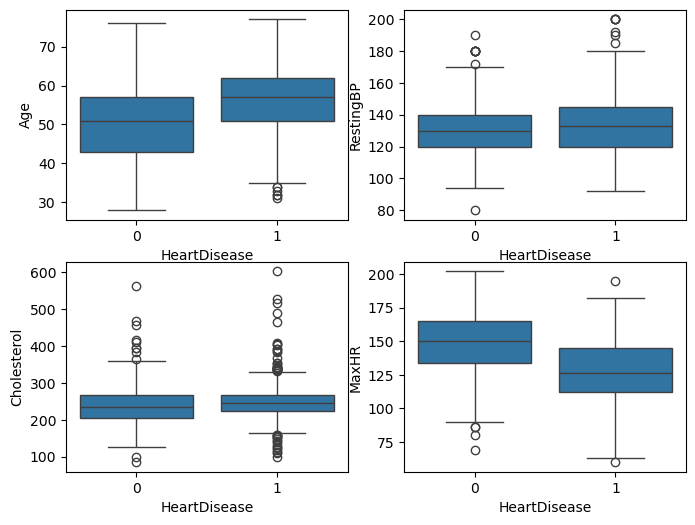

In [20]:
plt.figure(figsize=(8,6))
plt.subplot(2,2,1)
sns.boxplot(x='HeartDisease',y='Age',data=df)
plt.subplot(2,2,2)
sns.boxplot(x='HeartDisease',y='RestingBP',data=df)
plt.subplot(2,2,3)
sns.boxplot(x='HeartDisease',y='Cholesterol',data=df)
plt.subplot(2,2,4)
sns.boxplot(x='HeartDisease',y='MaxHR',data=df)

In [21]:
from scipy import stats

# Step 3: Define target and numeric features
target = 'HeartDisease'   # categorical target (0 or 1)
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']  # change if you have more numeric columns

# Step 4: Perform ANOVA for each numeric feature
anova_results = {}

for feature in numeric_features:
    # Split the numeric column based on target classes
    groups = [df[df[target] == cat][feature].dropna() for cat in df[target].unique()]

    # Perform one-way ANOVA
    f_stat, p_val = stats.f_oneway(*groups)

    # Store results
    anova_results[feature] = {'F-statistic': f_stat, 'p-value': p_val}

# Step 5: Convert results to a DataFrame for easy viewing
anova_df = pd.DataFrame(anova_results).T
anova_df = anova_df.sort_values(by='p-value')
anova_df

# Step 6: Optional - interpret results
significant_features = anova_df[anova_df['p-value'] < 0.05]
print("\n✅ Keep features (p < 0.05):")
significant_features


✅ Keep features (p < 0.05):


,F-statistic,p-value
Oldpeak,211.830497,3.077687e-43
MaxHR,168.844906,1.696843e-35
Age,77.398251,7.064616e-18
RestingBP,14.510030,1.489122e-04
Cholesterol,7.995855,4.792834e-03


In [22]:
#chi-square test
from scipy.stats import chi2_contingency

alpha=0.05
cat_features=['Sex','FastingBS','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']
chi2_results={}

for col in cat_features:
  contingency_table=pd.crosstab(df[col],df['HeartDisease'])
  chi2_stat,p_val,_,_=chi2_contingency(contingency_table)
  decision='Reject Null Hypothesis (keep feature)' if p_val<alpha else 'Fail to Reject Null Hypothesis (drop feature)'
  chi2_results[col]={'Chi2 Statistic':chi2_stat,'p-value':p_val,'Decision':decision}

chi2_df=pd.DataFrame(chi2_results).T
chi2_df=chi2_df.sort_values(by='p-value')
chi2_df

,Chi2 Statistic,p-value,Decision
ST_Slope,347.960516,0.0,Reject Null Hypothesis (keep feature)
ChestPainType,258.081413,0.0,Reject Null Hypothesis (keep feature)
ExerciseAngina,221.095316,0.0,Reject Null Hypothesis (keep feature)
Sex,83.909841,0.0,Reject Null Hypothesis (keep feature)
FastingBS,59.35358,0.0,Reject Null Hypothesis (keep feature)
RestingECG,10.893457,0.00431,Reject Null Hypothesis (keep feature)


In [9]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,Male,ATA,140.0,289.0,Normal,Normal,172,No,0.0,Up,0
1,49,Female,NAP,160.0,180.0,Normal,Normal,156,No,1.0,Flat,1
2,37,Male,ATA,130.0,283.0,Normal,ST,98,No,0.0,Up,0
3,48,Female,ASY,138.0,214.0,Normal,Normal,108,Yes,1.5,Flat,1
4,54,Male,NAP,150.0,195.0,Normal,Normal,122,No,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
894,45,Male,TA,110.0,264.0,Normal,Normal,132,No,1.2,Flat,1
895,68,Male,ASY,144.0,193.0,High,Normal,141,No,3.4,Flat,1
896,57,Male,ASY,130.0,131.0,Normal,Normal,115,Yes,1.2,Flat,1
897,57,Female,ATA,130.0,236.0,Normal,LVH,174,No,0.0,Flat,1


In [10]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

In [11]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
# from xgboost import XGBClassifier

In [14]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

preprocess = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', sparse_output=False), categorical),
                                             ("num", StandardScaler(), numerical)],remainder='passthrough')

### Logistic Regression

In [ ]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

preprocess = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', sparse_output=False), categorical),
                                             ("num", StandardScaler(), numerical)],remainder='passthrough')

model=LogisticRegression()

pipe = Pipeline([("preprocess", preprocess),
                 ("model", model)])

grid_r = {
    'model__penalty': ['l1','l2','elasticnet','none'],
    'model__C': [0.01,0.05,0.1,0.5,1.0],
    'model__solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
    'model__max_iter': [100,200,500,1000]
}

random_search = RandomizedSearchCV(estimator=pipe,param_distributions=grid_r,n_iter=100,cv=4,n_jobs=-1,verbose=1)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 4 folds for each of 400 candidates, totalling 1600 fits
Best Params: {'model__C': 0.5, 'model__max_iter': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best Score: 0.8566961514587212


accuracy 0.8666666666666667
f1 score 0.8823529411764706
              precision    recall  f1-score   support

           0       0.88      0.81      0.85        81
           1       0.86      0.91      0.88        99

    accuracy                           0.87       180
   macro avg       0.87      0.86      0.86       180
weighted avg       0.87      0.87      0.87       180



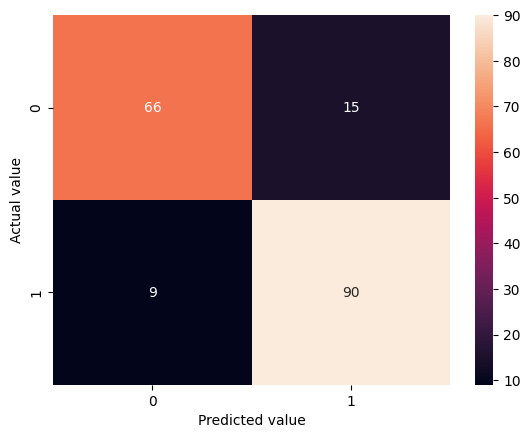

In [18]:
model=LogisticRegression(penalty='l1',C=0.5,solver='liblinear',max_iter=100)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('accuracy',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted value')
plt.ylabel('Actual value')

print(classification_report(y_test,y_pred))

### KNN

In [22]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

preprocess = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', sparse_output=False), categorical),
                                             ("num", StandardScaler(), numerical)],remainder='passthrough')

model= KNeighborsClassifier()

pipe = Pipeline([("preprocess", preprocess),
                 ("model", model)])

grid_r = {
    'model__n_neighbors': [3,5,7,9,11,13,15],
    'model__weights': ['uniform','distance'],
    'model__metric': ['euclidean','manhattan','minkowski'],
    'model__p': [1,2]
}

random_search = RandomizedSearchCV(estimator=pipe,param_distributions=grid_r,n_iter=100,cv=4,n_jobs=-1,verbose=1)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 4 folds for each of 84 candidates, totalling 336 fits
Best Params: {'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 13, 'model__metric': 'manhattan'}
Best Score: 0.8761716325263811


In [23]:
model = KNeighborsClassifier(weights = 'distance', p = 1, n_neighbors = 13, metric = 'manhattan')

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('accuracy',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))

accuracy 0.8611111111111112
f1 score 0.8780487804878049


### SVM

In [38]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

preprocess = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', sparse_output=False), categorical),
                                             ("num", StandardScaler(), numerical)],remainder='passthrough')

model=SVC(random_state=42)

pipe = Pipeline([("preprocess", preprocess),
                 ("model", model)])

grid_r  =   {'model__C'        : [0.01,0.1,1,10,100],
             'model__kernel'   : ['linear', 'rbf', 'poly', 'sigmoid'],
             'model__gamma'    : ['scale','auto',0.1,0.01,0.001,0.0001],
             'model__degree'   : [2,3,4,5]}
             
random_search = RandomizedSearchCV(estimator=pipe,param_distributions=grid_r,n_iter=150,cv=4,n_jobs=-1,verbose=1)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)


Fitting 4 folds for each of 150 candidates, totalling 600 fits
Best Params: {'model__kernel': 'poly', 'model__gamma': 'auto', 'model__degree': 2, 'model__C': 10}
Best Score: 0.8650294847920545


In [39]:
model = SVC(kernel= 'poly', gamma= 'auto', degree= 2, C= 10, random_state=42)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('accuracy',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))

accuracy 0.85
f1 score 0.8682926829268293


### Decision Trees

In [24]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

preprocess = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', sparse_output=False), categorical),
                                             ("num", StandardScaler(), numerical)],remainder='passthrough')

model=DecisionTreeClassifier()

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

grid_r  =   {'model__criterion'      : ['gini', 'entropy', 'log_loss'],
             'model__max_depth'      : [None, 5, 10, 15, 20],
             'model__min_samples_split' : [2, 5, 10],
             'model__min_samples_leaf'  : [1, 2, 4],
             'model__max_features'   : ['sqrt', 'log2', None]}
             


random_search = RandomizedSearchCV(estimator=pipe,param_distributions=grid_r,n_iter=100,cv=4,n_jobs=-1,verbose=1)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 4 folds for each of 100 candidates, totalling 400 fits
Best Params: {'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 5, 'model__criterion': 'gini'}
Best Score: 0.8330617628801986


In [25]:
model = DecisionTreeClassifier(min_samples_split= 5,min_samples_leaf= 4,
                               max_features= 'sqrt',max_depth= 5, criterion= 'gini')

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('accuracy',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))

accuracy 0.8333333333333334
f1 score 0.85


### Naive Bayes

In [21]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

preprocess = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', sparse_output=False), categorical),
                                             ("num", StandardScaler(), numerical)],remainder='passthrough')

model=GaussianNB()

pipe = Pipeline([("preprocess", preprocess),
                 ("model", model)])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('accuracy',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))

accuracy 0.8611111111111112
f1 score 0.8743718592964824


### Random Forest

In [28]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

preprocess = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', sparse_output=False), categorical),
                                             ("num", StandardScaler(), numerical)],remainder='passthrough')

model=RandomForestClassifier()

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

grid_r  =   {'model__n_estimators'   : [100, 200, 300, 500],
             'model__criterion'      : ['gini', 'entropy', 'log_loss'],
             'model__max_depth'      : [None, 10, 15, 20],
             'model__min_samples_split' : [2, 5, 10],
             'model__min_samples_leaf'  : [1, 2, 4],
             'model__max_features'   : ['sqrt', 'log2', None],
             'model__bootstrap'      : [True, False]}


random_search = RandomizedSearchCV(estimator=pipe,param_distributions=grid_r,n_iter=100,cv=4,n_jobs=-1,verbose=1)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 4 folds for each of 100 candidates, totalling 400 fits
Best Params: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__criterion': 'entropy', 'model__bootstrap': True}
Best Score: 0.8678305400372439


In [ ]:
model = RandomForestClassifier(n_estimators= 100,min_samples_split= 5,min_samples_leaf= 1,
                               max_features= 'sqrt',max_depth= 10, criterion= 'entropy', bootstrap= True)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('accuracy',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))

accuracy 0.8611111111111112
f1 score 0.8780487804878049


### Adaboost

In [23]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

preprocess = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', sparse_output=False), categorical),
                                             ("num", StandardScaler(), numerical)],remainder='passthrough')

model=AdaBoostClassifier()

pipe = Pipeline([("preprocess", preprocess),
                 ("model", model)])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('accuracy',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))

accuracy 0.8333333333333334
f1 score 0.8529411764705882


### Gradient Boost

In [24]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

preprocess = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', sparse_output=False), categorical),
                                             ("num", StandardScaler(), numerical)],remainder='passthrough')

model=GradientBoostingClassifier()

pipe = Pipeline([("preprocess", preprocess),
                 ("model", model)])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('accuracy',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))

accuracy 0.8611111111111112
f1 score 0.8756218905472637


### XG Boost

In [34]:
categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
numerical = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

preprocess = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop='first', sparse_output=False), categorical),
                                             ("num", StandardScaler(), numerical)],remainder='passthrough')

model=XGBClassifier(random_state=42)

pipe = Pipeline([("preprocess", preprocess),
                 ("model", model)])

grid_r  =   {'model__n_estimators'     : [100, 200, 300, 500],
             'model__learning_rate'    : [0.01,0.05,0.1,0.2],
             'model__max_depth'        : [3,5,7,10],
             'model__min_child_weight' : [1,3,5],
             'model__gamma'            : [0,0.1,0.3,0.5],
             'model__subsample'        : [0.6,0.8,1.0],
             'model__colsample_bytree' : [0.6,0.8,1.0]}


random_search = RandomizedSearchCV(estimator=pipe,param_distributions=grid_r,n_iter=100,cv=4,n_jobs=-1,verbose=1)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 4 folds for each of 100 candidates, totalling 400 fits
Best Params: {'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.3, 'model__colsample_bytree': 0.8}
Best Score: 0.8664571694599628


In [36]:
model = XGBClassifier(subsample= 0.8, n_estimators= 500, min_child_weight= 1, max_depth= 3, 
                      learning_rate= 0.01, gamma= 0.3, colsample_bytree= 0.8,random_state=42)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", model)
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('accuracy',accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))

accuracy 0.8555555555555555
f1 score 0.8725490196078431


### Exporting the Model

In [ ]:
import pickle

pickle.dump(df,open('df.pkl','wb'))
pickle.dump(pipe,open('pipe.pkl','wb'))